In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

In [2]:
from functions import dL_rosenbrock_1d
import pandas as pd
from src.optimizer import AdamScratch1D
from src.utils import AdamPlotter
import matplotlib.pyplot as plt
import numpy as np
from config import *

# DISCRETE-ADAM

In [3]:

optimizer = AdamScratch1D(
    dL = dL_rosenbrock_1d,
    lr=lr,
    beta1=beta1,
    beta2=beta2,
    epsilon=epsilon,
    epochs=epochs
)

theta_history, m_history, v_history, iterations = optimizer.solve(
    theta_initial=initial_theta,
    function_parameters=(c_value,)
    )

print(f"Final value of theta: {theta_history[-1]}")


Epoch: 50, theta=1.441362e+00, Error: 1.427005e-02
Epoch: 100, theta=4.629463e-01, Error: 3.610362e-03
Epoch: 150, theta=1.275356e+00, Error: 6.150016e-03
Epoch: 200, theta=7.267692e-01, Error: 3.981393e-03
Epoch: 250, theta=1.151202e+00, Error: 7.413855e-03
Epoch: 300, theta=8.492643e-01, Error: 4.291534e-03
Epoch: 350, theta=1.103957e+00, Error: 4.065854e-03
Epoch: 400, theta=8.992216e-01, Error: 1.448631e-03
Epoch: 450, theta=1.076327e+00, Error: 2.165867e-04
Epoch: 500, theta=9.412915e-01, Error: 1.919838e-03
Epoch: 550, theta=1.027355e+00, Error: 3.073688e-03
Epoch: 600, theta=9.982528e-01, Error: 2.969800e-03
Epoch: 650, theta=9.794378e-01, Error: 1.749169e-03
Epoch: 700, theta=1.023790e+00, Error: 4.307348e-05
Epoch: 750, theta=9.877411e-01, Error: 1.213687e-03
Epoch: 800, theta=9.949898e-01, Error: 1.178234e-03
Epoch: 850, theta=1.011561e+00, Error: 1.187891e-04
Epoch: 900, theta=9.955854e-01, Error: 7.177793e-04
Epoch: 950, theta=9.947363e-01, Error: 4.441609e-04
Epoch: 1000, 

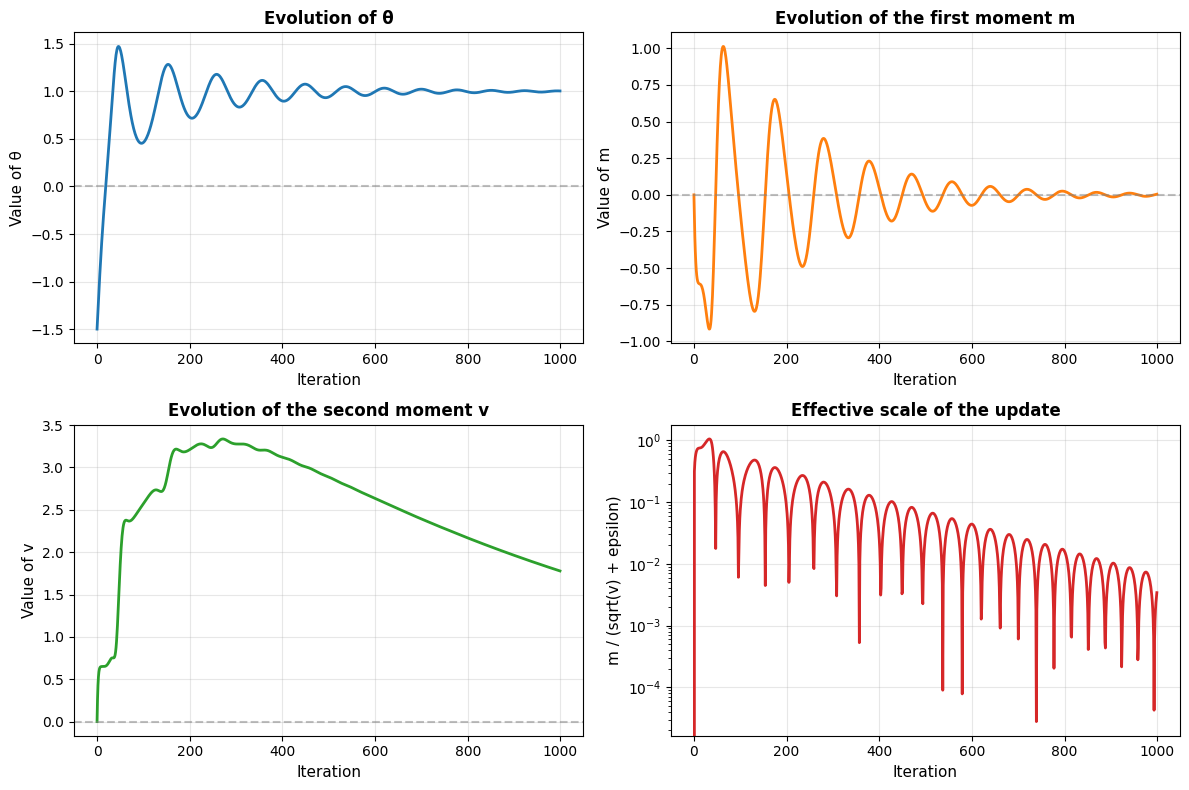

In [4]:
# Create Plotter and visualize
plotter = AdamPlotter(theta_history, m_history, v_history)

# Plot all
plotter.plot('all')
plt.show()

## Save Results

In [5]:
# Create DataFrame
df_discrete = pd.DataFrame({
    't': np.arange(len(theta_history)),
    'theta_history': theta_history,
    'theta_dot_history': None,
    'theta_ddot_history': None,
    'm_history': m_history,
    'v_history': v_history
})

# Save to CSV
df_discrete.to_csv(f'results/c_{c_value}_results_initial_theta_{initial_theta}_lr_{lr}_beta1_{beta1}_beta2_{beta2}.csv', index=False)
print(f"Results saved in 'results/c_{c_value}_results_initial_theta_{initial_theta}_lr_{lr}_beta1_{beta1}_beta2_{beta2}.csv'")
print(f"Total rows: {len(df_discrete)}")

Results saved in 'results/c_1.5_results_initial_theta_-1.5_lr_0.1_beta1_0.99_beta2_0.999.csv'
Total rows: 1000
